In [17]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, accuracy_score

In [2]:
df = pd.read_csv("C:\\Users\\atchi\\Downloads\\StudentsPerformance.csv")
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [3]:
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [4]:
X = df.drop("math score", axis=1)
y = df["math score"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [6]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

In [7]:
print("\nLINEAR REGRESSION RESULTS")
print("Mean Absolute Error:", mae)


LINEAR REGRESSION RESULTS
Mean Absolute Error: 4.1301450780040545


In [8]:
print("Predicted Math Score:", y_pred[:5])

Predicted Math Score: [77.11855699 57.07358    79.35766788 77.15093246 84.91283746]


In [11]:
df["Pass_Fail"] = df["math score"].apply(
    lambda x: 1 if x >= 40 else 0
)

In [12]:
X_class = df.drop(["math score", "Pass_Fail"], axis=1)
y_class = df["Pass_Fail"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_class,
    y_class,
    test_size=0.2,
    random_state=42
)

In [14]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_class = log_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred_class)

In [15]:
print("\nCLASSIFICATION RESULTS")
print("Accuracy:", accuracy)


CLASSIFICATION RESULTS
Accuracy: 0.99


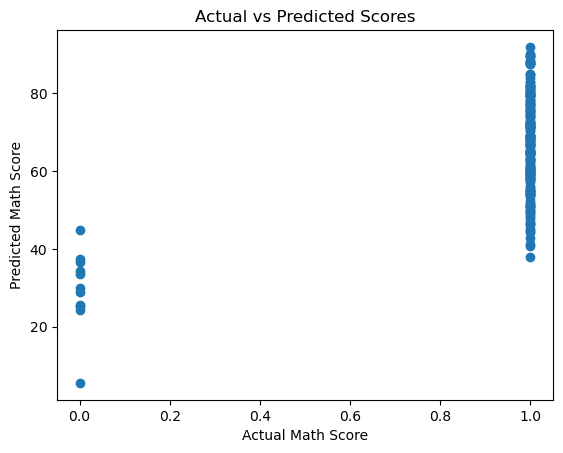

In [19]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Math Score")
plt.ylabel("Predicted Math Score")
plt.title("Actual vs Predicted Scores")
plt.show()